## Установка библиотек

In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import torch.optim as optim
from torchvision import datasets, transforms, models
import numpy as np
import os
import torch
import glob
import random
from torch.utils.data import DataLoader, random_split
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import os
import subprocess

## Проверка видеокарты

In [ ]:
print("=" * 60)
print("ПРОВЕРКА СИСТЕМЫ И ВИДЕОКАРТЫ")
print("=" * 60)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")
print(f"Number of CUDA devices: {torch.cuda.device_count() if torch.cuda.is_available() else 0}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
else:
    print("CUDA не доступна!")
    
    try:
        nvidia_smi = subprocess.check_output(["nvidia-smi"], shell=True).decode()
        print("NVIDIA драйверы установлены, но PyTorch не видит GPU")
    except:
        print("NVIDIA драйверы не установлены или nvidia-smi не доступен")


if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nИспользуется GPU: {torch.cuda.get_device_name()}")
else:
    device = torch.device("cpu")
    print(f"\nИспользуется CPU")

print(f"Selected device: {device}")

ПРОВЕРКА СИСТЕМЫ И ВИДЕОКАРТЫ
PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
Number of CUDA devices: 1
GPU 0: NVIDIA GeForce RTX 3060 Laptop GPU
  Memory: 6.0 GB

Используется GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Selected device: cuda


In [19]:
!nvidia-smi

Fri Nov  7 16:18:39 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 527.99       Driver Version: 527.99       CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   50C    P8    14W /  80W |   2752MiB /  6144MiB |      3%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## Обучение модели

Using device: cuda
ПРОВЕРКА СТРУКТУРЫ ДАННЫХ
✓ Найдена папка: ../fast_created_augmented_data/train
  Содержимое: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']

🎯 Используем путь: ../fast_created_augmented_data/train
Загрузка данных из: ../fast_created_augmented_data/train
Найдено классов: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']
Всего изображений: 2210
Тренировочные данные: 1768 изображений
Тестовые данные: 442 изображений

📊 ИНФОРМАЦИЯ О ДАННЫХ:
Classes: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']
Number of classes: 11
Training samples: 1768
Test samples: 442


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🚀 НАЧАЛО ОБУЧЕНИЯ
Epoch [1/15], Step [0/111], Loss: 2.4908
Epoch [1/15], Step [10/111], Loss: 1.6951
Epoch [1/15], Step [20/111], Loss: 1.0028
Epoch [1/15], Step [30/111], Loss: 0.7960
Epoch [1/15], Step [40/111], Loss: 0.5979
Epoch [1/15], Step [50/111], Loss: 0.4822
Epoch [1/15], Step [60/111], Loss: 0.3780
Epoch [1/15], Step [70/111], Loss: 0.7465
Epoch [1/15], Step [80/111], Loss: 0.6469
Epoch [1/15], Step [90/111], Loss: 0.9871
Epoch [1/15], Step [100/111], Loss: 1.0627
Epoch [1/15], Step [110/111], Loss: 0.5428
Epoch [1/15], Loss: 0.9529, Accuracy: 85.97%
--------------------------------------------------
Epoch [2/15], Step [0/111], Loss: 0.6873
Epoch [2/15], Step [10/111], Loss: 0.4230
Epoch [2/15], Step [20/111], Loss: 0.3101
Epoch [2/15], Step [30/111], Loss: 0.6398
Epoch [2/15], Step [40/111], Loss: 0.4890
Epoch [2/15], Step [50/111], Loss: 0.3492
Epoch [2/15], Step [60/111], Loss: 0.1115
Epoch [2/15], Step [70/111], Loss: 0.1435
Epoch [2/15], Step [80/111], Loss: 0.2301
Epo

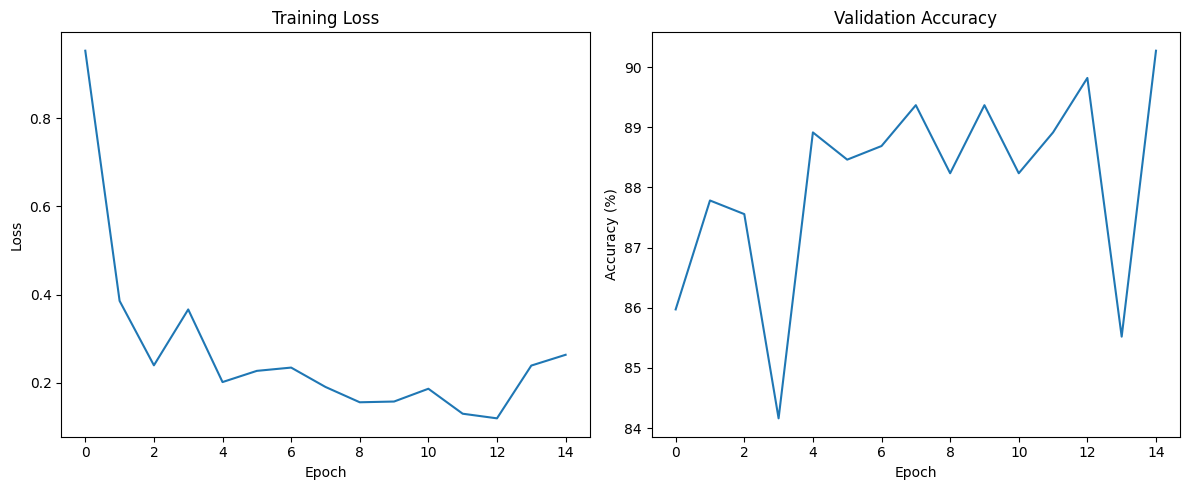

✅ Model saved!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_split_data(data_path, train_ratio=0.8):
    """
    Загружает все данные и разделяет на тренировочную и тестовую выборки
    """
    print(f"Загрузка данных из: {data_path}")
    
    if not os.path.exists(data_path):
        print(f"Ошибка: Папка {data_path} не существует!")
        print("Содержимое текущей директории:")
        print(os.listdir('.'))
        return None, None, None
    
    full_dataset = datasets.ImageFolder(root=data_path, transform=train_transform)
    print(f"Найдено классов: {full_dataset.classes}")
    print(f"Всего изображений: {len(full_dataset)}")
    
    train_size = int(train_ratio * len(full_dataset))
    test_size = len(full_dataset) - train_size
    
    print(f"Тренировочные данные: {train_size} изображений")
    print(f"Тестовые данные: {test_size} изображений")
    
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    
    test_dataset_full = datasets.ImageFolder(root=data_path, transform=val_transform)
    test_dataset = torch.utils.data.Subset(test_dataset_full, test_dataset.indices)
    
    return train_dataset, test_dataset, full_dataset.classes

def create_resnet_model(num_classes, pretrained=True):
    model = models.resnet18(pretrained=pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=25):
    model = model.to(device)
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}')
        
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        
        train_losses.append(epoch_loss)
        val_accuracies.append(epoch_accuracy)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')
        print('-' * 50)
    
    return train_losses, val_accuracies

def check_data_structure():
    """Проверяет существование различных возможных путей"""
    possible_paths = [
        "../fast_created_augmented_data/train",
        "fast_created_augmented_data/train", 
        "./fast_created_augmented_data/train"
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Найдена папка: {path}")
            print(f"Содержимое: {os.listdir(path)}")
            return path
        else:
            print(f"Папка не найдена: {path}")
    
    return None

if __name__ == "__main__":
    print("=" * 60)
    print("ПРОВЕРКА СТРУКТУРЫ ДАННЫХ")
    print("=" * 60)
    
    data_path = check_data_structure()
    
    if data_path is None:
        print("\nНе удалось найти папку с данными!")
        exit()
    
    print(f"\nИспользуем путь: {data_path}")
    
    try:
        train_dataset, test_dataset, class_names = load_and_split_data(data_path, train_ratio=0.8)
        
        if train_dataset is None:
            exit()
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
        
        print(f"\nИНФОРМАЦИЯ О ДАННЫХ:")
        print(f"Classes: {class_names}")
        print(f"Number of classes: {len(class_names)}")
        print(f"Training samples: {len(train_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        num_classes = len(class_names)
        model = create_resnet_model(num_classes, pretrained=True)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        print(f"\nНАЧАЛО ОБУЧЕНИЯ")
        print("=" * 60)
        
        train_losses, val_accuracies = train_model(
            model, train_loader, test_loader, criterion, optimizer, epochs=15
        )
        
        if len(train_losses) > 0:
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses)
            plt.title('Training Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            
            plt.subplot(1, 2, 2)
            plt.plot(val_accuracies)
            plt.title('Validation Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy (%)')
            
            plt.tight_layout()
            plt.show()
            
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'model_architecture': 'resnet18'
            }, 'phone_fast_created_augmented_data_resnet18.pth')
            
            print("✅ Model saved!")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

## Предсказание изображений

Архитектура модели: resnet18
Количество классов: 11
Модель успешно загружена с cuda
Модель загружена для тестирования
Классы модели: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']

ЗАПУСК ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ
Поиск изображений в phone_data...
Поиск в папке: 110
Поиск в папке: 130
Поиск в папке: 150
Поиск в папке: 170
Поиск в папке: 190
Поиск в папке: 210
Поиск в папке: 230
Поиск в папке: 250
Поиск в папке: 50
Поиск в папке: 70
Поиск в папке: 90
Найдено всего изображений: 221

Начинаем предсказание для 100 изображений...

Изображение 1/100
Файл: IMG_20251002_191441.jpg
Истинный класс: 110
Предсказание: 110
Уверенность: 100.00%
Результат: ✅ ПРАВИЛЬНО

Изображение 2/100
Файл: IMG_20251002_200138_1.jpg
Истинный класс: 190
Предсказание: 190
Уверенность: 52.24%
Результат: ✅ ПРАВИЛЬНО

Изображение 3/100
Файл: IMG_20251002_192813.jpg
Истинный класс: 130
Предсказание: 130
Уверенность: 100.00%
Результат: ✅ ПРАВИЛЬНО

Изображение 4/100
Файл: IMG_20251002_190

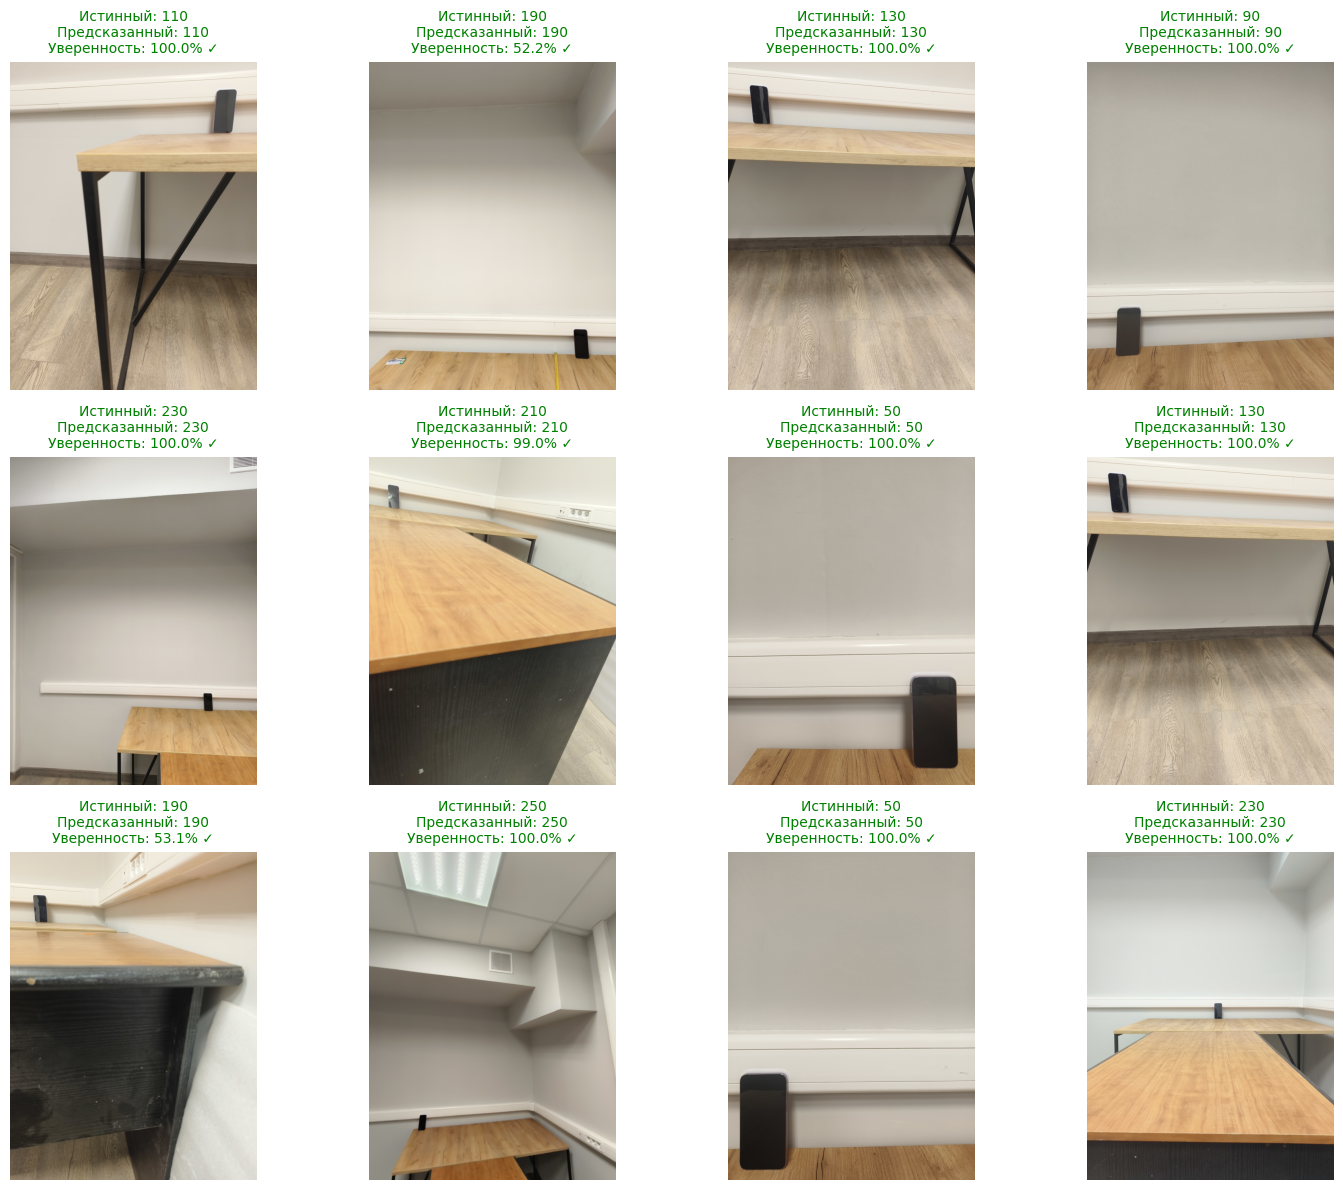

Предсказание для изображения: C:\Users\user\Desktop\MIPT year 2\Инженерный практикум\Working_directory\Convolutional-Neural-Network\phone_data\50\IMG_20251002_183844.jpg
Предсказанный класс: 50
Уверенность: 100.00%

Вероятности по всем классам:
   110: 0.00%
   130: 0.00%
   150: 0.00%
   170: 0.00%
   190: 0.00%
   210: 0.00%
   230: 0.00%
   250: 0.00%
   50: 100.00%
   70: 0.00%
   90: 0.00%


In [24]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import random
import matplotlib.pyplot as plt
import numpy as np

def load_trained_model(model_path, num_classes=None, device='cpu'):
    """
    Загружает обученную модель
    
    Args:
        model_path: путь к файлу модели
        num_classes: количество классов (если None, будет определено автоматически)
        device: устройство для загрузки модели
    
    Returns:
        model: загруженная модель
        class_names: список названий классов
    """
    try:
        checkpoint = torch.load(model_path, map_location=device)
        
        if 'class_names' in checkpoint:
            class_names = checkpoint['class_names']
            num_classes = len(class_names)
        else:
            print("class_names не найдены в чекпоинте")
            class_names = None
        
        if 'model_architecture' in checkpoint:
            arch = checkpoint['model_architecture']
        else:
            arch = 'resnet18' 
        
        print(f"Архитектура модели: {arch}")
        print(f"Количество классов: {num_classes}")
        
        if arch == 'resnet18':
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif arch == 'resnet50':
            model = models.resnet50(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            raise ValueError(f"Неизвестная архитектура: {arch}")
        
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        
        model.to(device)
        model.eval()
        
        print(f"Модель успешно загружена с {device}")
        
        return model, class_names
        
    except Exception as e:
        print(f"Ошибка при загрузке модели: {e}")
        raise

def predict_multiple_images(model, data_folder, class_names, device, num_images=20, transform=None):
    """
    Предсказывает классы для нескольких изображений из phone_data
    
    Args:
        model: обученная модель
        data_folder: путь к папке phone_data
        class_names: список названий классов
        device: устройство для вычислений
        num_images: количество изображений для предсказания
        transform: трансформации для изображений
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    all_images = []
    image_classes = []
    
    print("Поиск изображений в phone_data...")
    
    for class_name in class_names:
        class_path = os.path.join(data_folder, class_name)
        if os.path.exists(class_path):
            print(f"Поиск в папке: {class_name}")
            for file in os.listdir(class_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    full_path = os.path.join(class_path, file)
                    all_images.append(full_path)
                    image_classes.append(class_name)
    
    print(f"Найдено всего изображений: {len(all_images)}")
    
    if len(all_images) == 0:
        print("Не найдено изображений в phone_data!")
        return []
    
    if len(all_images) < num_images:
        selected_indices = range(len(all_images))
        print(f"Найдено только {len(all_images)} изображений, будем использовать все")
    else:
        selected_indices = random.sample(range(len(all_images)), num_images)
    
    results = []
    
    print(f"\nНачинаем предсказание для {len(selected_indices)} изображений...")
    print("=" * 80)
    
    for i, idx in enumerate(selected_indices):
        image_path = all_images[idx]
        true_class = image_classes[idx]
        
        print(f"\nИзображение {i+1}/{len(selected_indices)}")
        print(f"Файл: {os.path.basename(image_path)}")
        print(f"Истинный класс: {true_class}")
        
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            model.eval()
            with torch.no_grad():
                outputs = model(image_tensor)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                predicted_prob, predicted_class = torch.max(probabilities, 1)
            
            predicted_class_name = class_names[predicted_class.item()]
            confidence = predicted_prob.item()
            
            is_correct = (predicted_class_name == true_class)
            
            result = {
                'image_path': image_path,
                'true_class': true_class,
                'predicted_class': predicted_class_name,
                'confidence': confidence,
                'is_correct': is_correct,
                'all_probabilities': probabilities.cpu().numpy()[0]
            }
            
            results.append(result)
            
            status = "✅ ПРАВИЛЬНО" if is_correct else "❌ ОШИБКА"
            print(f"Предсказание: {predicted_class_name}")
            print(f"Уверенность: {confidence:.2%}")
            print(f"Результат: {status}")
            
        except Exception as e:
            print(f"Ошибка при обработке изображения: {e}")
            continue
    
    return results

def predict_image(model, image_path, class_names, device, transform=None):
    """
    Предсказывает класс для одного изображения
    
    Args:
        model: обученная модель
        image_path: путь к изображению
        class_names: список названий классов
        device: устройство для вычислений
        transform: трансформации для изображений
    
    Returns:
        dict: словарь с результатами предсказания
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    print(f"Предсказание для изображения: {image_path}")
    
    try:
        if not os.path.exists(image_path):
            print(f"Файл не найден: {image_path}")
            return None
        
        image = Image.open(image_path).convert('RGB')
        
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            predicted_prob, predicted_class = torch.max(probabilities, 1)
        
        predicted_class_name = class_names[predicted_class.item()]
        confidence = predicted_prob.item()
        
        all_probs = probabilities.cpu().numpy()[0]
        
        result = {
            'image_path': image_path,
            'predicted_class': predicted_class_name,
            'confidence': confidence,
            'all_probabilities': all_probs,
            'class_probabilities': {
                class_name: prob for class_name, prob in zip(class_names, all_probs)
            }
        }
        
        print(f"Предсказанный класс: {predicted_class_name}")
        print(f"Уверенность: {confidence:.2%}")
        print("\nВероятности по всем классам:")
        for class_name, prob in zip(class_names, all_probs):
            print(f"   {class_name}: {prob:.2%}")
        
        return result
        
    except Exception as e:
        print(f"Ошибка при обработке изображения: {e}")
        import traceback
        traceback.print_exc()
        return None

def predict_image_simple(model, image_path, class_names, device):
    """
    Упрощенная версия функции предсказания (только основной результат)
    
    Returns:
        str: название предсказанного класса
        float: уверенность предсказания
    """
    result = predict_image(model, image_path, class_names, device)
    if result:
        return result['predicted_class'], result['confidence']
    else:
        return None, 0.0

def display_statistics(results, class_names):
    """
    Отображает статистику по результатам предсказаний
    """
    if not results:
        print("Нет результатов для отображения статистики")
        return
    
    print("\n" + "=" * 80)
    print("СТАТИСТИКА ПРЕДСКАЗАНИЙ")
    print("=" * 80)
    
    total = len(results)
    correct = sum(1 for r in results if r['is_correct'])
    accuracy = correct / total * 100
    
    print(f"📊 Общее количество изображений: {total}")
    print(f"✅ Правильные предсказания: {correct}")
    print(f"❌ Неправильные предсказания: {total - correct}")
    print(f"🎯 Точность: {accuracy:.2f}%")
    
    print(f"\nДЕТАЛЬНАЯ СТАТИСТИКА ПО КЛАССАМ:")
    
    for class_name in class_names:
        class_results = [r for r in results if r['true_class'] == class_name]
        if class_results:
            class_correct = sum(1 for r in class_results if r['is_correct'])
            class_total = len(class_results)
            class_accuracy = class_correct / class_total * 100 if class_total > 0 else 0
            
            print(f"  {class_name}: {class_correct}/{class_total} ({class_accuracy:.1f}%)")

def plot_predictions_grid(results, class_names, max_display=12):
    """
    Визуализирует предсказания в виде сетки изображений
    """
    if not results:
        return
    
    display_results = results[:max_display]
    
    cols = 4
    rows = (len(display_results) + cols - 1) // cols
    
    plt.figure(figsize=(15, 4 * rows))
    
    for i, result in enumerate(display_results):
        plt.subplot(rows, cols, i + 1)
        
        try:
            image = Image.open(result['image_path']).convert('RGB')
            plt.imshow(image)
            
            title_color = 'green' if result['is_correct'] else 'red'
            status = "✓" if result['is_correct'] else "✗"
            
            plt.title(
                f"Истинный: {result['true_class']}\n"
                f"Предсказанный: {result['predicted_class']}\n"
                f"Уверенность: {result['confidence']:.1%} {status}",
                color=title_color,
                fontsize=10
            )
            plt.axis('off')
            
        except Exception as e:
            plt.title(f"Ошибка загрузки\n{os.path.basename(result['image_path'])}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        model, class_names = load_trained_model('phone_fast_created_augmented_data_resnet18.pth', num_classes, device)
        print("Модель загружена для тестирования")
        print(f"Классы модели: {class_names}")
        
        phone_data_path = "phone_data"
        
        if not os.path.exists(phone_data_path):
            alternative_paths = [
                "Convolutional-Neural-Network/phone_data",
                "./Convolutional-Neural-Network/phone_data", 
                "phone_data/MY_data/test",
                "./phone_data"
            ]
            
            for path in alternative_paths:
                if os.path.exists(path):
                    phone_data_path = path
                    print(f"Найден путь: {phone_data_path}")
                    break
            else:
                print("Не удалось найти папку phone_data!")
                exit()
        
        print(f"\nЗАПУСК ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ")
        print("=" * 80)
        
        results = predict_multiple_images(
            model=model,
            data_folder=phone_data_path,
            class_names=class_names,
            device=device,
            num_images=100
        )
        
        display_statistics(results, class_names)
        
        if results:
            print(f"\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
            plot_predictions_grid(results, class_names)
        
    except Exception as e:
        print(f"Ошибка при тестировании: {e}")
        import traceback
        traceback.print_exc()

def test_specific_class(model, class_names, device, target_class, num_images=5):
    """
    Тестирует модель на изображениях конкретного класса
    """
    phone_data_path = "phone_data"
    
    if not os.path.exists(phone_data_path):
        phone_data_path = "Convolutional-Neural-Network/phone_data"
    
    class_path = os.path.join(phone_data_path, target_class)
    
    if not os.path.exists(class_path):
        print(f"Папка класса {target_class} не найдена!")
        return []
    
    images = []
    for file in os.listdir(class_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            images.append(os.path.join(class_path, file))
    
    if not images:
        print(f"Не найдено изображений в классе {target_class}!")
        return []
    
    images = images[:num_images]
    
    print(f"\nТЕСТИРОВАНИЕ КЛАССА {target_class} ({len(images)} изображений)")
    print("=" * 60)
    
    results = []
    for i, image_path in enumerate(images):
        result = predict_image(model, image_path, class_names, device)
        if result:
            result['true_class'] = target_class
            result['is_correct'] = (result['predicted_class'] == target_class)
            results.append(result)
            
            status = "✅" if result['is_correct'] else "❌"
            print(f"{i+1}. {os.path.basename(image_path)}: "
                  f"{result['predicted_class']} ({result['confidence']:.1%}) {status}")
    
    return results

# Пример использования для тестирования конкретного класса:
# test_specific_class(model, class_names, device, "50", num_images=5)
image_path = r"C:\Users\user\Desktop\MIPT year 2\Инженерный практикум\Working_directory\Convolutional-Neural-Network\phone_data\50\IMG_20251002_183844.jpg"
predicted_class, confidence = predict_image_simple(model, image_path, class_names, device)
# print(f"!!!!!!!!!!!!!! Класс: {predicted_class}, Уверенность: {confidence:.1%}")

In [9]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os


def predict_image(model, image_path, class_names, device, transform=None):
    """
    Предсказывает класс для одного изображения
    
    Args:
        model: обученная модель
        image_path: путь к изображению
        class_names: список названий классов
        device: устройство для вычислений
        transform: трансформации для изображений
    
    Returns:
        dict: словарь с результатами предсказания
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    print(f"Предсказание для изображения: {image_path}")
    
    try:
        if not os.path.exists(image_path):
            print(f"Файл не найден: {image_path}")
            return None
        
        image = Image.open(image_path).convert('RGB')
        
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            predicted_prob, predicted_class = torch.max(probabilities, 1)
        
        predicted_class_name = class_names[predicted_class.item()]
        confidence = predicted_prob.item()
        
        all_probs = probabilities.cpu().numpy()[0]
        
        result = {
            'image_path': image_path,
            'predicted_class': predicted_class_name,
            'confidence': confidence,
            'all_probabilities': all_probs,
            'class_probabilities': {
                class_name: prob for class_name, prob in zip(class_names, all_probs)
            }
        }
        
        print(f"Предсказанный класс: {predicted_class_name}")
        print(f"Уверенность: {confidence:.2%}")
        print("\nВероятности по всем классам:")
        for class_name, prob in zip(class_names, all_probs):
            print(f"{class_name}: {prob:.2%}")
        
        return result
        
    except Exception as e:
        print(f"Ошибка при обработке изображения: {e}")
        return None

if __name__ == "__main__":

    image_path = r"C:\Users\user\Desktop\MIPT year 2\Инженерный практикум\Working_directory\Convolutional-Neural-Network\phone_data\50\IMG_20251002_183844.jpg"
    
    result = predict_image(model, image_path, class_names, device)
    if result:
        predicted_class = result['predicted_class']
        confidence = result['confidence']
    print(f"Класс: {predicted_class}, Уверенность: {confidence:.1%}")

Предсказание для изображения: C:\Users\user\Desktop\MIPT year 2\Инженерный практикум\Working_directory\Convolutional-Neural-Network\phone_data\50\IMG_20251002_183844.jpg
Предсказанный класс: 50
Уверенность: 100.00%

Вероятности по всем классам:
110: 0.00%
130: 0.00%
150: 0.00%
170: 0.00%
190: 0.00%
210: 0.00%
230: 0.00%
250: 0.00%
50: 100.00%
70: 0.00%
90: 0.00%
Класс: 50, Уверенность: 100.0%


## Обучение модели на другом наборе данных (вторая аугментация)

Using device: cuda
ПРОВЕРКА СТРУКТУРЫ ДАННЫХ
✓ Найдена папка: ../geometry_preserved_augmented_data/train
  Содержимое: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']

🎯 Используем путь: ../geometry_preserved_augmented_data/train
Загрузка данных из: ../geometry_preserved_augmented_data/train
Найдено классов: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']
Всего изображений: 8840
Тренировочные данные: 7072 изображений
Тестовые данные: 1768 изображений

📊 ИНФОРМАЦИЯ О ДАННЫХ:
Classes: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']
Number of classes: 11
Training samples: 7072
Test samples: 1768


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🚀 НАЧАЛО ОБУЧЕНИЯ
Epoch [1/15], Step [0/442], Loss: 2.6469
Epoch [1/15], Step [10/442], Loss: 2.4678
Epoch [1/15], Step [20/442], Loss: 2.0413
Epoch [1/15], Step [30/442], Loss: 2.0085
Epoch [1/15], Step [40/442], Loss: 1.4458
Epoch [1/15], Step [50/442], Loss: 2.1573
Epoch [1/15], Step [60/442], Loss: 1.3201
Epoch [1/15], Step [70/442], Loss: 1.2419
Epoch [1/15], Step [80/442], Loss: 1.1698
Epoch [1/15], Step [90/442], Loss: 1.0977
Epoch [1/15], Step [100/442], Loss: 1.0436
Epoch [1/15], Step [110/442], Loss: 0.7553
Epoch [1/15], Step [120/442], Loss: 1.1171
Epoch [1/15], Step [130/442], Loss: 1.0522
Epoch [1/15], Step [140/442], Loss: 0.6839
Epoch [1/15], Step [150/442], Loss: 0.8093
Epoch [1/15], Step [160/442], Loss: 0.5179
Epoch [1/15], Step [170/442], Loss: 0.9361
Epoch [1/15], Step [180/442], Loss: 0.7380
Epoch [1/15], Step [190/442], Loss: 1.0031
Epoch [1/15], Step [200/442], Loss: 0.6966
Epoch [1/15], Step [210/442], Loss: 0.9466
Epoch [1/15], Step [220/442], Loss: 0.9266
Epo

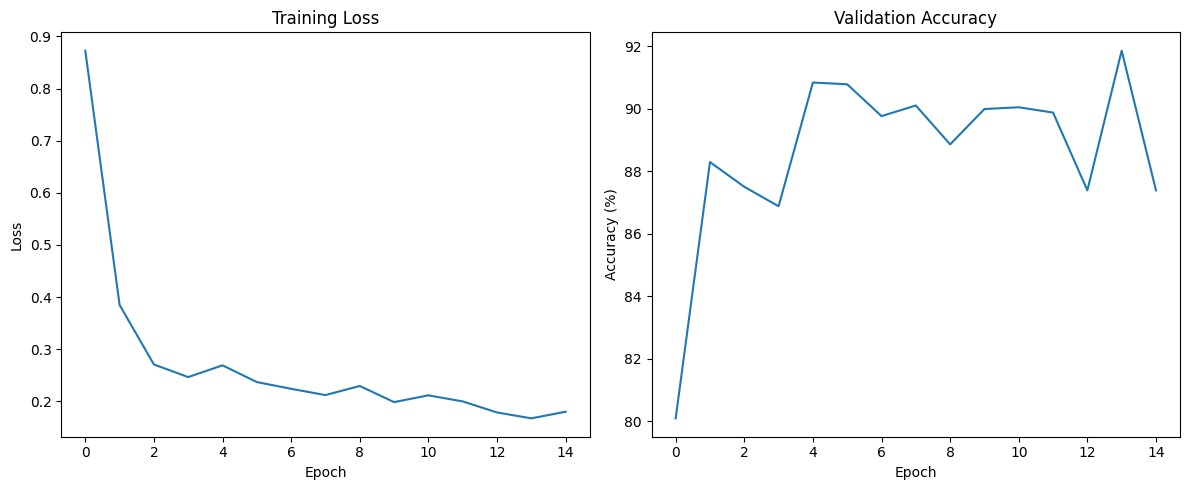

✅ Model saved!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_and_split_data(data_path, train_ratio=0.8):
    """
    Загружает все данные и разделяет на тренировочную и тестовую выборки
    """
    print(f"Загрузка данных из: {data_path}")
    
    if not os.path.exists(data_path):
        print(f"Ошибка: Папка {data_path} не существует!")
        print("Содержимое текущей директории:")
        print(os.listdir('.'))
        return None, None, None
    
    full_dataset = datasets.ImageFolder(root=data_path, transform=train_transform)
    print(f"Найдено классов: {full_dataset.classes}")
    print(f"Всего изображений: {len(full_dataset)}")
    
    train_size = int(train_ratio * len(full_dataset))
    test_size = len(full_dataset) - train_size
    
    print(f"Тренировочные данные: {train_size} изображений")
    print(f"Тестовые данные: {test_size} изображений")
    
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    
    test_dataset_full = datasets.ImageFolder(root=data_path, transform=val_transform)
    test_dataset = torch.utils.data.Subset(test_dataset_full, test_dataset.indices)
    
    return train_dataset, test_dataset, full_dataset.classes

def create_resnet_model(num_classes, pretrained=True):
    model = models.resnet18(pretrained=pretrained)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=25):
    model = model.to(device)
    train_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
            if batch_idx % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}')
        
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total
        
        train_losses.append(epoch_loss)
        val_accuracies.append(epoch_accuracy)
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')
        print('-' * 50)
    
    return train_losses, val_accuracies

def check_data_structure():
    """Проверяет существование различных возможных путей"""
    possible_paths = [
        "../geometry_preserved_augmented_data/train",
        "geometry_preserved_augmented_data/train", 
        "./geometry_preserved_augmented_data/train"
    ]
    
    for path in possible_paths:
        if os.path.exists(path):
            print(f"Найдена папка: {path}")
            print(f"Содержимое: {os.listdir(path)}")
            return path
        else:
            print(f"Папка не найдена: {path}")
    
    return None

if __name__ == "__main__":
    print("=" * 60)
    print("ПРОВЕРКА СТРУКТУРЫ ДАННЫХ")
    print("=" * 60)
    
    data_path = check_data_structure()
    
    if data_path is None:
        print("\nНе удалось найти папку с данными!")
        exit()
    
    print(f"\nИспользуем путь: {data_path}")
    
    try:
        train_dataset, test_dataset, class_names = load_and_split_data(data_path, train_ratio=0.8)
        
        if train_dataset is None:
            exit()
        
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
        
        print(f"\nИНФОРМАЦИЯ О ДАННЫХ:")
        print(f"Classes: {class_names}")
        print(f"Number of classes: {len(class_names)}")
        print(f"Training samples: {len(train_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        num_classes = len(class_names)
        model = create_resnet_model(num_classes, pretrained=True)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
        
        print(f"\nНАЧАЛО ОБУЧЕНИЯ")
        print("=" * 60)
        
        train_losses, val_accuracies = train_model(
            model, train_loader, test_loader, criterion, optimizer, epochs=15
        )
        
        if len(train_losses) > 0:
            plt.figure(figsize=(12, 5))
            plt.subplot(1, 2, 1)
            plt.plot(train_losses)
            plt.title('Training Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            
            plt.subplot(1, 2, 2)
            plt.plot(val_accuracies)
            plt.title('Validation Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy (%)')
            
            plt.tight_layout()
            plt.show()
            
            torch.save({
                'model_state_dict': model.state_dict(),
                'class_names': class_names,
                'model_architecture': 'resnet18'
            }, 'phone_geometry_preserved_augmented_data_resnet18.pth')
            
            print("✅ Model saved!")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

Архитектура модели: resnet18
Количество классов: 11
Модель успешно загружена с cuda
Модель загружена для тестирования
Классы модели: ['110', '130', '150', '170', '190', '210', '230', '250', '50', '70', '90']

ЗАПУСК ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ
Поиск изображений в phone_data...
Поиск в папке: 110
Поиск в папке: 130
Поиск в папке: 150
Поиск в папке: 170
Поиск в папке: 190
Поиск в папке: 210
Поиск в папке: 230
Поиск в папке: 250
Поиск в папке: 50
Поиск в папке: 70
Поиск в папке: 90
Найдено всего изображений: 221

Начинаем предсказание для 100 изображений...

Изображение 1/100
Файл: IMG_20251002_190236_1.jpg
Истинный класс: 90
Предсказание: 90
Уверенность: 100.00%
Результат: ✅ ПРАВИЛЬНО

Изображение 2/100
Файл: IMG_20251002_192847_1.jpg
Истинный класс: 130
Предсказание: 130
Уверенность: 99.98%
Результат: ✅ ПРАВИЛЬНО

Изображение 3/100
Файл: IMG_20251002_204351.jpg
Истинный класс: 210
Предсказание: 210
Уверенность: 99.99%
Результат: ✅ ПРАВИЛЬНО

Изображение 4/100
Файл: IMG_20251002_1928

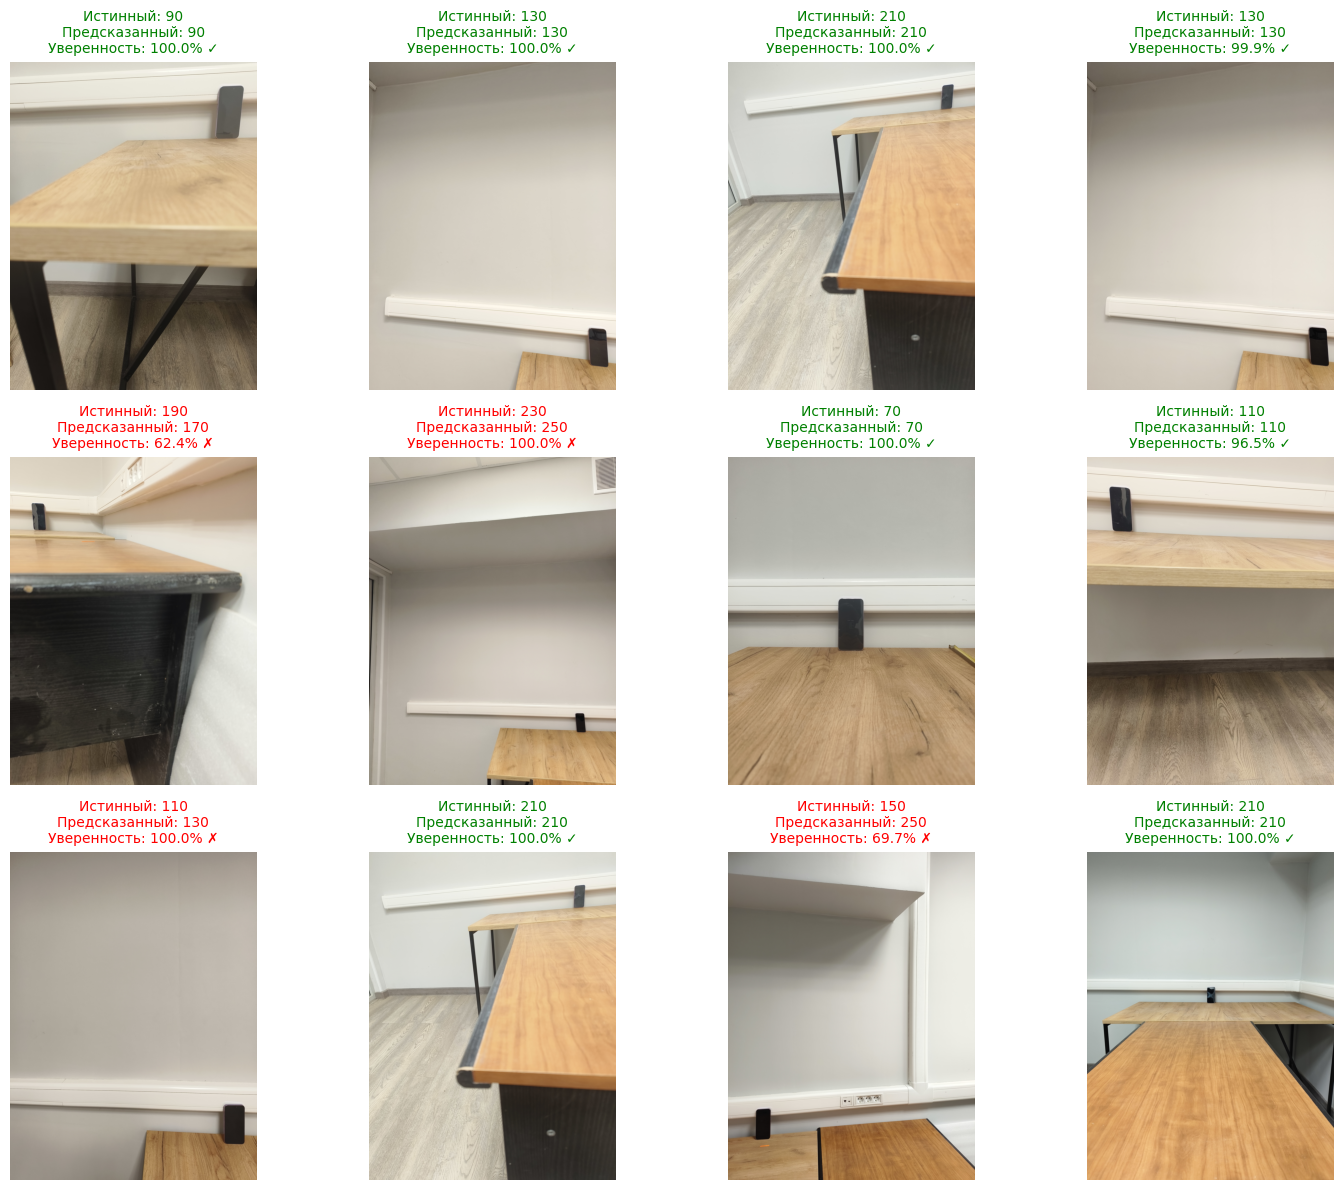

Предсказание для изображения: C:\Users\user\Desktop\MIPT year 2\Инженерный практикум\Working_directory\Convolutional-Neural-Network\phone_data\50\IMG_20251002_183844.jpg
Предсказанный класс: 50
Уверенность: 100.00%

Вероятности по всем классам:
   110: 0.00%
   130: 0.00%
   150: 0.00%
   170: 0.00%
   190: 0.00%
   210: 0.00%
   230: 0.00%
   250: 0.00%
   50: 100.00%
   70: 0.00%
   90: 0.00%


In [25]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import random
import matplotlib.pyplot as plt
import numpy as np

def load_trained_model(model_path, num_classes=None, device='cpu'):
    """
    Загружает обученную модель
    
    Args:
        model_path: путь к файлу модели
        num_classes: количество классов (если None, будет определено автоматически)
        device: устройство для загрузки модели
    
    Returns:
        model: загруженная модель
        class_names: список названий классов
    """
    try:
        checkpoint = torch.load(model_path, map_location=device)
        
        if 'class_names' in checkpoint:
            class_names = checkpoint['class_names']
            num_classes = len(class_names)
        else:
            print("class_names не найдены в чекпоинте")
            class_names = None
        
        if 'model_architecture' in checkpoint:
            arch = checkpoint['model_architecture']
        else:
            arch = 'resnet18' 
        
        print(f"Архитектура модели: {arch}")
        print(f"Количество классов: {num_classes}")
        
        if arch == 'resnet18':
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif arch == 'resnet50':
            model = models.resnet50(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        else:
            raise ValueError(f"Неизвестная архитектура: {arch}")
        
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
        
        model.to(device)
        model.eval()
        
        print(f"Модель успешно загружена с {device}")
        
        return model, class_names
        
    except Exception as e:
        print(f"Ошибка при загрузке модели: {e}")
        raise

def predict_multiple_images(model, data_folder, class_names, device, num_images=20, transform=None):
    """
    Предсказывает классы для нескольких изображений из phone_data
    
    Args:
        model: обученная модель
        data_folder: путь к папке phone_data
        class_names: список названий классов
        device: устройство для вычислений
        num_images: количество изображений для предсказания
        transform: трансформации для изображений
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    all_images = []
    image_classes = []
    
    print("Поиск изображений в phone_data...")
    
    for class_name in class_names:
        class_path = os.path.join(data_folder, class_name)
        if os.path.exists(class_path):
            print(f"Поиск в папке: {class_name}")
            for file in os.listdir(class_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    full_path = os.path.join(class_path, file)
                    all_images.append(full_path)
                    image_classes.append(class_name)
    
    print(f"Найдено всего изображений: {len(all_images)}")
    
    if len(all_images) == 0:
        print("Не найдено изображений в phone_data!")
        return []
    
    if len(all_images) < num_images:
        selected_indices = range(len(all_images))
        print(f"Найдено только {len(all_images)} изображений, будем использовать все")
    else:
        selected_indices = random.sample(range(len(all_images)), num_images)
    
    results = []
    
    print(f"\nНачинаем предсказание для {len(selected_indices)} изображений...")
    print("=" * 80)
    
    for i, idx in enumerate(selected_indices):
        image_path = all_images[idx]
        true_class = image_classes[idx]
        
        print(f"\nИзображение {i+1}/{len(selected_indices)}")
        print(f"Файл: {os.path.basename(image_path)}")
        print(f"Истинный класс: {true_class}")
        
        try:
            image = Image.open(image_path).convert('RGB')
            image_tensor = transform(image).unsqueeze(0).to(device)
            
            model.eval()
            with torch.no_grad():
                outputs = model(image_tensor)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                predicted_prob, predicted_class = torch.max(probabilities, 1)
            
            predicted_class_name = class_names[predicted_class.item()]
            confidence = predicted_prob.item()
            
            is_correct = (predicted_class_name == true_class)
            
            result = {
                'image_path': image_path,
                'true_class': true_class,
                'predicted_class': predicted_class_name,
                'confidence': confidence,
                'is_correct': is_correct,
                'all_probabilities': probabilities.cpu().numpy()[0]
            }
            
            results.append(result)
            
            status = "✅ ПРАВИЛЬНО" if is_correct else "❌ ОШИБКА"
            print(f"Предсказание: {predicted_class_name}")
            print(f"Уверенность: {confidence:.2%}")
            print(f"Результат: {status}")
            
        except Exception as e:
            print(f"Ошибка при обработке изображения: {e}")
            continue
    
    return results

def predict_image(model, image_path, class_names, device, transform=None):
    """
    Предсказывает класс для одного изображения
    
    Args:
        model: обученная модель
        image_path: путь к изображению
        class_names: список названий классов
        device: устройство для вычислений
        transform: трансформации для изображений
    
    Returns:
        dict: словарь с результатами предсказания
    """
    
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    print(f"Предсказание для изображения: {image_path}")
    
    try:
        if not os.path.exists(image_path):
            print(f"Файл не найден: {image_path}")
            return None
        
        image = Image.open(image_path).convert('RGB')
        
        image_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            predicted_prob, predicted_class = torch.max(probabilities, 1)
        
        predicted_class_name = class_names[predicted_class.item()]
        confidence = predicted_prob.item()
        
        all_probs = probabilities.cpu().numpy()[0]
        
        result = {
            'image_path': image_path,
            'predicted_class': predicted_class_name,
            'confidence': confidence,
            'all_probabilities': all_probs,
            'class_probabilities': {
                class_name: prob for class_name, prob in zip(class_names, all_probs)
            }
        }
        
        print(f"Предсказанный класс: {predicted_class_name}")
        print(f"Уверенность: {confidence:.2%}")
        print("\nВероятности по всем классам:")
        for class_name, prob in zip(class_names, all_probs):
            print(f"   {class_name}: {prob:.2%}")
        
        return result
        
    except Exception as e:
        print(f"Ошибка при обработке изображения: {e}")
        import traceback
        traceback.print_exc()
        return None

def predict_image_simple(model, image_path, class_names, device):
    """
    Упрощенная версия функции предсказания (только основной результат)
    
    Returns:
        str: название предсказанного класса
        float: уверенность предсказания
    """
    result = predict_image(model, image_path, class_names, device)
    if result:
        return result['predicted_class'], result['confidence']
    else:
        return None, 0.0

def display_statistics(results, class_names):
    """
    Отображает статистику по результатам предсказаний
    """
    if not results:
        print("Нет результатов для отображения статистики")
        return
    
    print("\n" + "=" * 80)
    print("СТАТИСТИКА ПРЕДСКАЗАНИЙ")
    print("=" * 80)
    
    total = len(results)
    correct = sum(1 for r in results if r['is_correct'])
    accuracy = correct / total * 100
    
    print(f"📊 Общее количество изображений: {total}")
    print(f"✅ Правильные предсказания: {correct}")
    print(f"❌ Неправильные предсказания: {total - correct}")
    print(f"🎯 Точность: {accuracy:.2f}%")
    
    print(f"\nДЕТАЛЬНАЯ СТАТИСТИКА ПО КЛАССАМ:")
    
    for class_name in class_names:
        class_results = [r for r in results if r['true_class'] == class_name]
        if class_results:
            class_correct = sum(1 for r in class_results if r['is_correct'])
            class_total = len(class_results)
            class_accuracy = class_correct / class_total * 100 if class_total > 0 else 0
            
            print(f"  {class_name}: {class_correct}/{class_total} ({class_accuracy:.1f}%)")

def plot_predictions_grid(results, class_names, max_display=12):
    """
    Визуализирует предсказания в виде сетки изображений
    """
    if not results:
        return
    
    display_results = results[:max_display]
    
    cols = 4
    rows = (len(display_results) + cols - 1) // cols
    
    plt.figure(figsize=(15, 4 * rows))
    
    for i, result in enumerate(display_results):
        plt.subplot(rows, cols, i + 1)
        
        try:
            image = Image.open(result['image_path']).convert('RGB')
            plt.imshow(image)
            
            title_color = 'green' if result['is_correct'] else 'red'
            status = "✓" if result['is_correct'] else "✗"
            
            plt.title(
                f"Истинный: {result['true_class']}\n"
                f"Предсказанный: {result['predicted_class']}\n"
                f"Уверенность: {result['confidence']:.1%} {status}",
                color=title_color,
                fontsize=10
            )
            plt.axis('off')
            
        except Exception as e:
            plt.title(f"Ошибка загрузки\n{os.path.basename(result['image_path'])}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        model, class_names = load_trained_model('phone_geometry_preserved_augmented_data_resnet18.pth', num_classes, device)
        print("Модель загружена для тестирования")
        print(f"Классы модели: {class_names}")
        
        phone_data_path = "phone_data"
        
        if not os.path.exists(phone_data_path):
            alternative_paths = [
                "Convolutional-Neural-Network/phone_data",
                "./Convolutional-Neural-Network/phone_data", 
                "phone_data/MY_data/test",
                "./phone_data"
            ]
            
            for path in alternative_paths:
                if os.path.exists(path):
                    phone_data_path = path
                    print(f"Найден путь: {phone_data_path}")
                    break
            else:
                print("Не удалось найти папку phone_data!")
                exit()
        
        print(f"\nЗАПУСК ПРЕДСКАЗАНИЯ ДЛЯ 20 ИЗОБРАЖЕНИЙ")
        print("=" * 80)
        
        results = predict_multiple_images(
            model=model,
            data_folder=phone_data_path,
            class_names=class_names,
            device=device,
            num_images=100
        )
        
        display_statistics(results, class_names)
        
        if results:
            print(f"\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
            plot_predictions_grid(results, class_names)
        
    except Exception as e:
        print(f"Ошибка при тестировании: {e}")
        import traceback
        traceback.print_exc()

def test_specific_class(model, class_names, device, target_class, num_images=5):
    """
    Тестирует модель на изображениях конкретного класса
    """
    phone_data_path = "phone_data"
    
    if not os.path.exists(phone_data_path):
        phone_data_path = "Convolutional-Neural-Network/phone_data"
    
    class_path = os.path.join(phone_data_path, target_class)
    
    if not os.path.exists(class_path):
        print(f"Папка класса {target_class} не найдена!")
        return []
    
    images = []
    for file in os.listdir(class_path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            images.append(os.path.join(class_path, file))
    
    if not images:
        print(f"Не найдено изображений в классе {target_class}!")
        return []
    
    images = images[:num_images]
    
    print(f"\nТЕСТИРОВАНИЕ КЛАССА {target_class} ({len(images)} изображений)")
    print("=" * 60)
    
    results = []
    for i, image_path in enumerate(images):
        result = predict_image(model, image_path, class_names, device)
        if result:
            result['true_class'] = target_class
            result['is_correct'] = (result['predicted_class'] == target_class)
            results.append(result)
            
            status = "✅" if result['is_correct'] else "❌"
            print(f"{i+1}. {os.path.basename(image_path)}: "
                  f"{result['predicted_class']} ({result['confidence']:.1%}) {status}")
    
    return results

# Пример использования для тестирования конкретного класса:
# test_specific_class(model, class_names, device, "50", num_images=5)
image_path = r"C:\Users\user\Desktop\MIPT year 2\Инженерный практикум\Working_directory\Convolutional-Neural-Network\phone_data\50\IMG_20251002_183844.jpg"
predicted_class, confidence = predict_image_simple(model, image_path, class_names, device)
# print(f"!!!!!!!!!!!!!! Класс: {predicted_class}, Уверенность: {confidence:.1%}")